In [1]:

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

In [2]:
df = pd.read_csv('cleaned_dataset.csv')
df.head()

C:\Users\mihir\AppData\Local\Temp\ipykernel_30732\795541288.py:1: DtypeWarning: Columns (2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('cleaned_dataset.csv')


,asteroid_id,asteroid_name,near_earth_object,potentially_hazardous,absolute_magnitude,diameter_km,surface_reflectivity,diameter_uncertainty_km,orbit_solution_id,orbit_epoch,...,uncertainty_orbital_inclination,uncertainty_longitude_ascending_node,uncertainty_argument_perihelion,uncertainty_mean_anomaly,uncertainty_aphelion_distance,uncertainty_mean_motion,uncertainty_time_perihelion_passage,uncertainty_orbital_period,asteroid_class,orbit_fit_rms
0,2000001,1 Ceres,False,False,3.40,939.400,0.0900,0.200,JPL 47,2458600.5,...,4.610000e-09,6.170000e-08,6.620000e-08,7.820000e-09,1.110000e-11,1.200000e-12,3.780000e-08,9.420000e-09,MBA,0.43301
1,2000002,2 Pallas,False,False,4.20,545.000,0.1010,18.000,JPL 37,2459000.5,...,3.470000e-06,6.270000e-06,9.130000e-06,8.860000e-06,4.960000e-09,4.650000e-10,4.080000e-05,3.680000e-06,MBA,0.35936
2,2000003,3 Juno,False,False,5.33,246.596,0.2140,10.594,JPL 112,2459000.5,...,3.220000e-06,1.660000e-05,1.770000e-05,8.110000e-06,4.360000e-09,4.410000e-10,3.530000e-05,3.110000e-06,MBA,0.33848
3,2000004,4 Vesta,False,False,3.00,525.400,0.4228,0.200,JPL 35,2458600.5,...,2.170000e-07,3.880000e-07,1.790000e-07,1.210000e-06,1.650000e-09,2.610000e-10,4.100000e-06,1.270000e-06,MBA,0.39980
4,2000005,5 Astraea,False,False,6.90,106.699,0.2740,3.140,JPL 114,2459000.5,...,2.740000e-06,2.890000e-05,2.980000e-05,8.300000e-06,4.730000e-09,5.520000e-10,3.470000e-05,3.490000e-06,MBA,0.52191


In [3]:
# Check unique values in the column
print("Unique values in 'potentially_hazardous':", df["potentially_hazardous"].unique())
print("Unique values in 'near_earth_object':", df["near_earth_object"].unique())

# Check data types
print(df[["potentially_hazardous", "near_earth_object"]].dtypes)

Unique values in 'potentially_hazardous': [False True 'FALSE' 'N' 'TRUE']
Unique values in 'near_earth_object': [False True 'FALSE' 'TRUE' 'Unknown']
potentially_hazardous    object
near_earth_object        object
dtype: object


In [4]:
# Convert all values to uppercase strings for consistency
df["potentially_hazardous"] = df["potentially_hazardous"].astype(str).str.upper()
df["near_earth_object"] = df["near_earth_object"].astype(str).str.upper()

# Define mappings
hazardous_mapping = {
    "TRUE": 1, 
    "FALSE": 0, 
    "N": 0  # 'N' treated as non-hazardous
}

neo_mapping = {
    "TRUE": 1, 
    "FALSE": 0, 
    "UNKNOWN": 0  # assuming 'Unknown' means not confirmed as NEO
}

# Apply mappings and convert to int
df["potentially_hazardous"] = df["potentially_hazardous"].map(hazardous_mapping).astype(int)
df["near_earth_object"] = df["near_earth_object"].map(neo_mapping).astype(int)

In [5]:
# Check unique values again to confirm proper conversion
print("Unique values in 'potentially_hazardous':", df["potentially_hazardous"].unique())
print("Unique values in 'near_earth_object':", df["near_earth_object"].unique())

Unique values in 'potentially_hazardous': [0 1]
Unique values in 'near_earth_object': [0 1]


In [6]:
# Import necessary libraries
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# Select relevant features + target
selected_features_rf = [
    'absolute_magnitude', 'diameter_km', 'surface_reflectivity',
    'orbital_eccentricity', 'semi_major_axis_au', 'perihelion_distance_au',
    'orbital_inclination_deg', 'earth_moid_au', 'mean_motion_deg_day', 'orbit_fit_rms',
    'potentially_hazardous'
]

# Create a new DataFrame
df_rf = df[selected_features_rf]

# Separate features and label
X = df_rf.drop(columns=['potentially_hazardous'])
y = df_rf['potentially_hazardous']

# Train-Test Split (Stratified 70/30)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# Apply SMOTE to the training data
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Print shapes
print(f"Training Set Shape after SMOTE: {X_train_smote.shape}")
print(f"Testing Set Shape: {X_test.shape}")


Training Set Shape after SMOTE: (1339040, 10)
Testing Set Shape: (287558, 10)


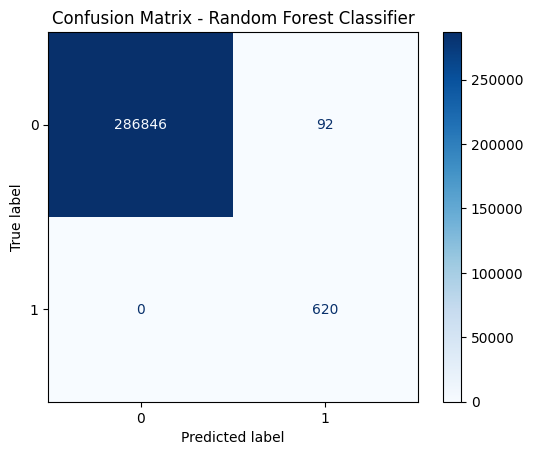

Classification Report - Random Forest Classifier
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    286938
           1       0.87      1.00      0.93       620

    accuracy                           1.00    287558
   macro avg       0.94      1.00      0.97    287558
weighted avg       1.00      1.00      1.00    287558



In [7]:
# Import Random Forest library
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Sample 20,000 rows for training to make it faster
X_train_sample_rf = X_train_smote.sample(n=20000, random_state=42)
y_train_sample_rf = y_train_smote.loc[X_train_sample_rf.index]

# Train Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_sample_rf, y_train_sample_rf)

# Predict on the full test set
y_pred_rf = rf_model.predict(X_test)

# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=rf_model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix - Random Forest Classifier')
plt.show()

# Classification Report
print("Classification Report - Random Forest Classifier")
print(classification_report(y_test, y_pred_rf))
